Dataset Preview:
        Date     Product  Quantity  Price Customer_ID Region  Total_Sales  \
0 2024-01-01       Phone         7  37300     CUST001   East       261100   
1 2024-01-02  Headphones         4  15406     CUST002  North        61624   
2 2024-01-03       Phone         2  21746     CUST003   West        43492   
3 2024-01-04  Headphones         1  30895     CUST004   East        30895   
4 2024-01-05      Laptop         8  39835     CUST005  North       318680   

   Month  Year  
0      1  2024  
1      1  2024  
2      1  2024  
3      1  2024  
4      1  2024  

===== KEY METRICS =====
Total Sales: 12365048
Total Orders: 100
Total Quantity Sold: 478


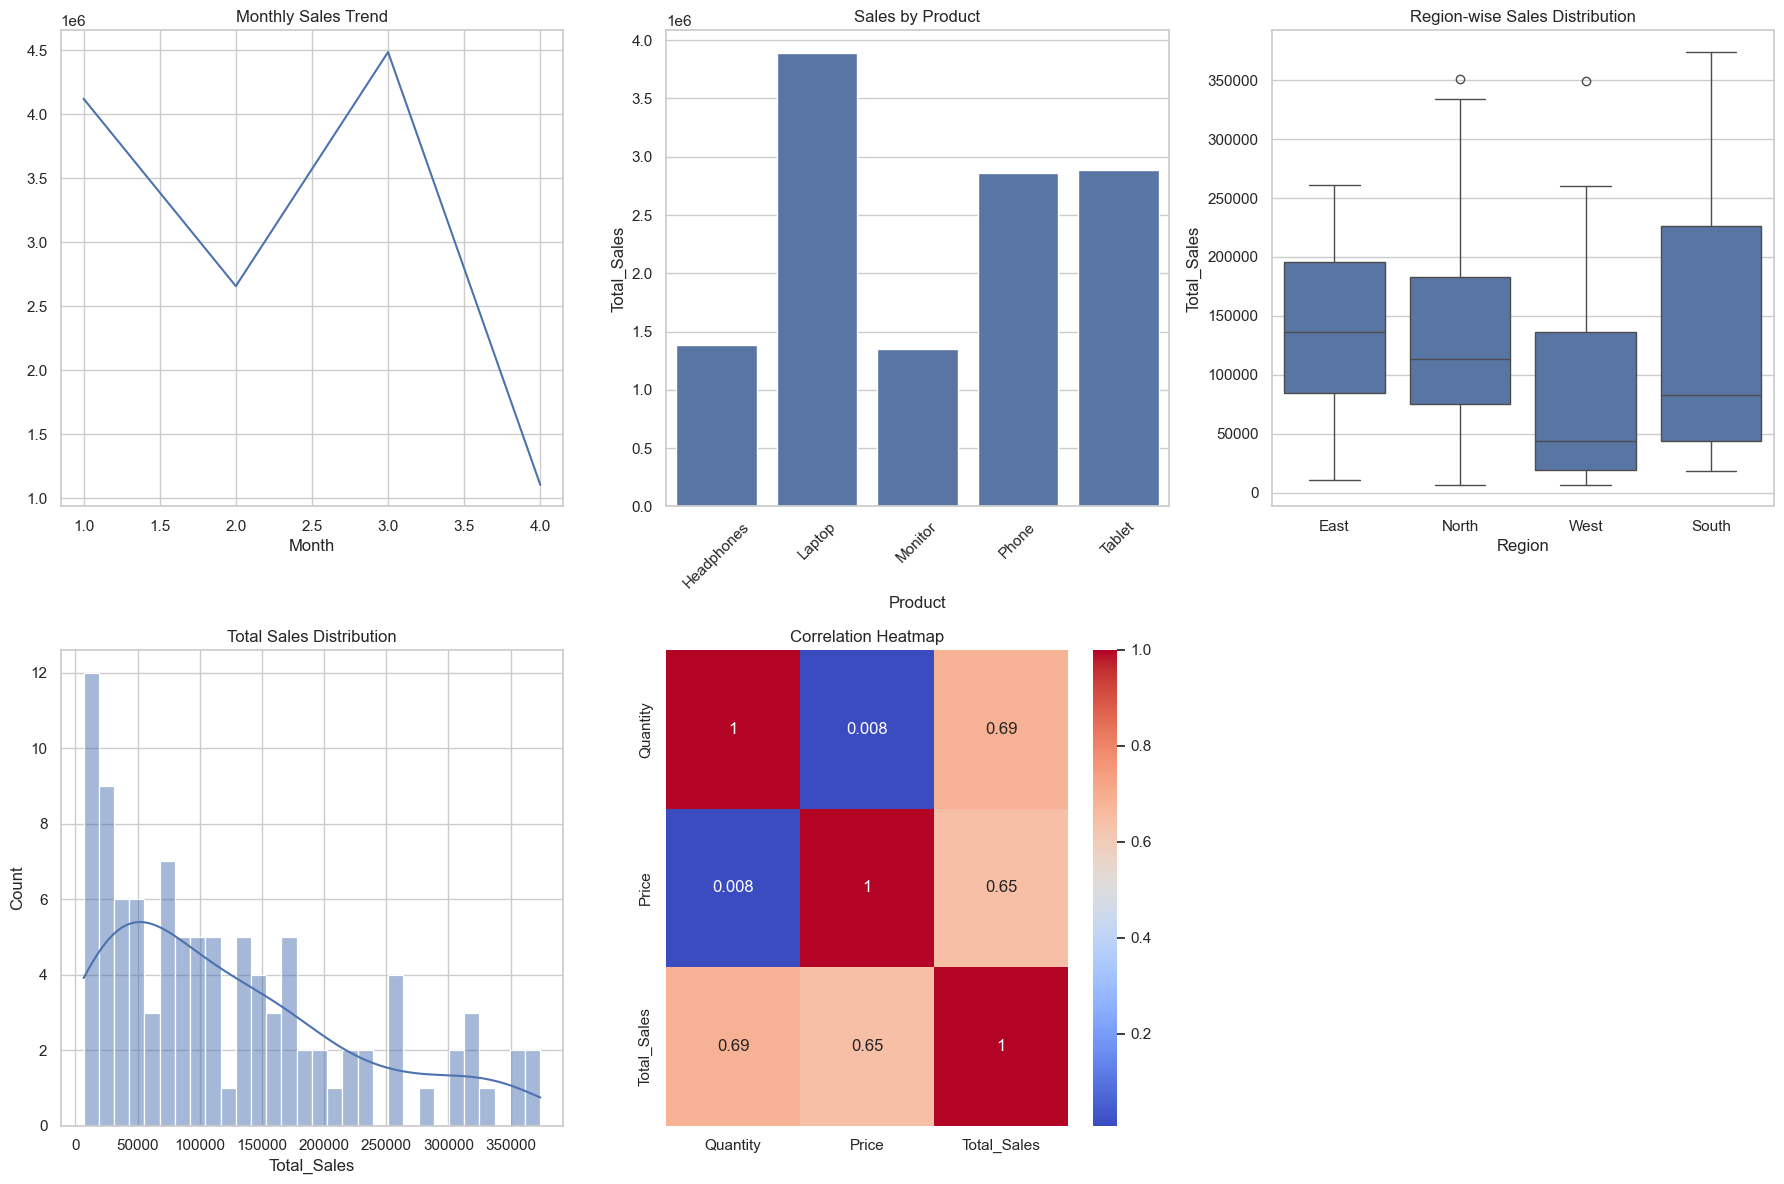

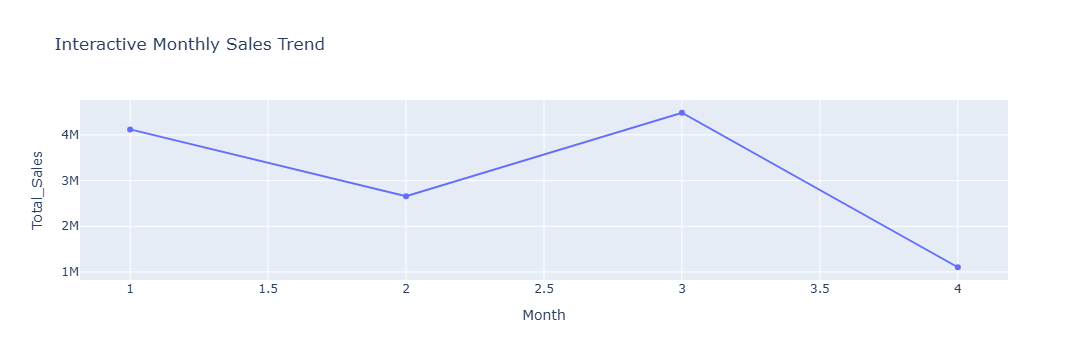

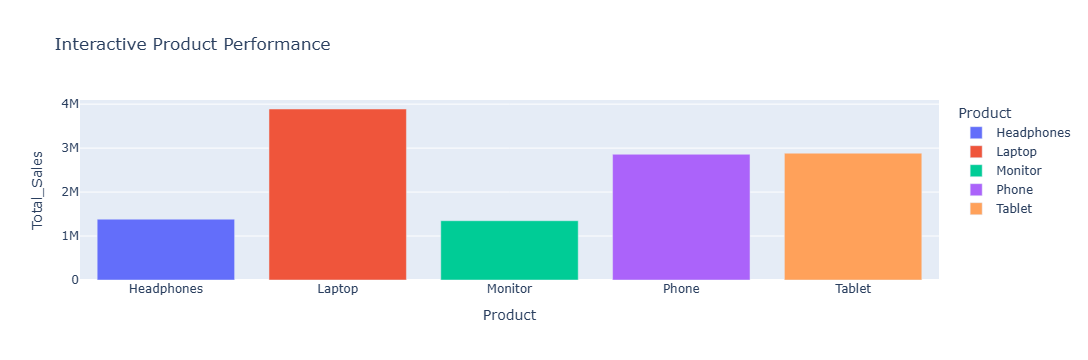

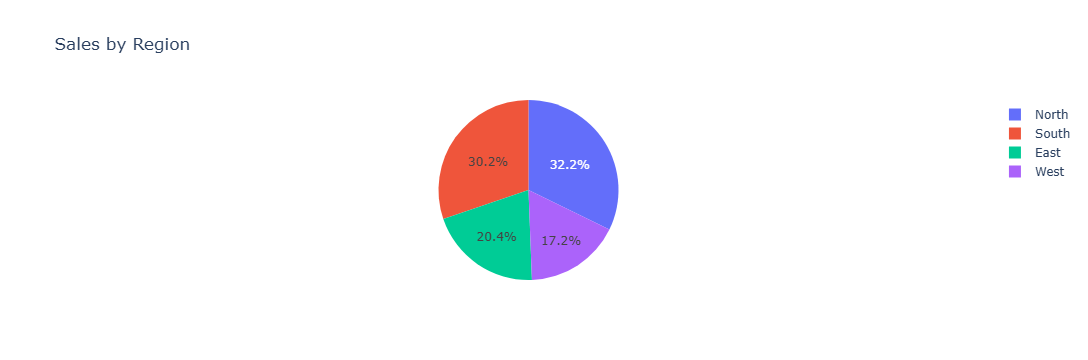

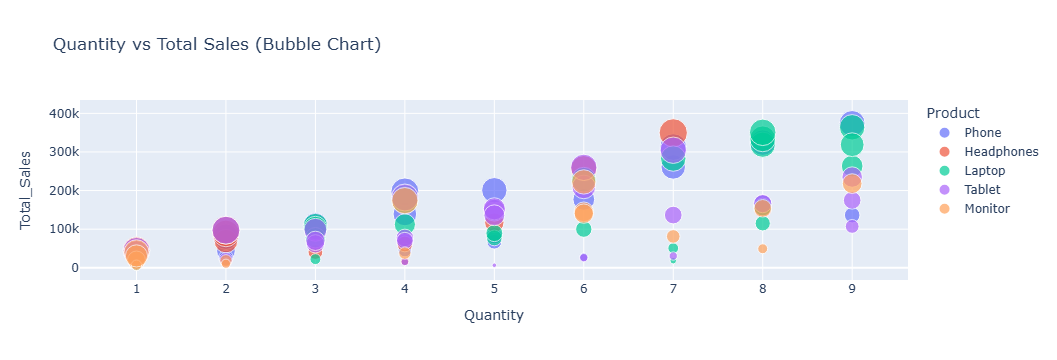

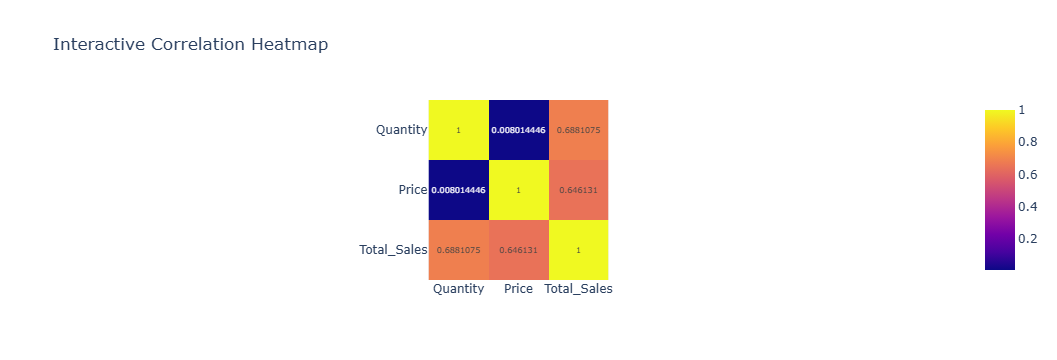

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sales = pd.read_csv(r"C:\Users\sumix\Downloads\sales_data (1).csv")
sales['Date'] = pd.to_datetime(sales['Date'])
sales['Month'] = sales['Date'].dt.month
sales['Year'] = sales['Date'].dt.year

print("Dataset Preview:")
print(sales.head())

total_sales = sales['Total_Sales'].sum()
total_orders = sales.shape[0]
total_quantity = sales['Quantity'].sum()

print("\n===== KEY METRICS =====")
print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)

sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

plt.subplot(2,3,1)
monthly_sales = sales.groupby('Month')['Total_Sales'].sum()
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend")

plt.subplot(2,3,2)
product_sales = sales.groupby('Product')['Total_Sales'].sum().reset_index()
sns.barplot(data=product_sales, x='Product', y='Total_Sales')
plt.title("Sales by Product")
plt.xticks(rotation=45)

plt.subplot(2,3,3)
sns.boxplot(data=sales, x='Region', y='Total_Sales')
plt.title("Region-wise Sales Distribution")

plt.subplot(2,3,4)
sns.histplot(sales['Total_Sales'], kde=True, bins=30)
plt.title("Total Sales Distribution")

plt.subplot(2,3,5)
numeric_cols = sales[['Quantity', 'Price', 'Total_Sales']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


fig1 = px.line(
    sales.groupby('Month')['Total_Sales'].sum().reset_index(),
    x='Month',
    y='Total_Sales',
    title="Interactive Monthly Sales Trend",
    markers=True
)
fig1.show()

fig2 = px.bar(
    product_sales,
    x='Product',
    y='Total_Sales',
    color='Product',
    title="Interactive Product Performance"
)
fig2.show()

fig3 = px.pie(
    sales,
    names='Region',
    values='Total_Sales',
    title="Sales by Region"
)
fig3.show()

fig4 = px.scatter(
    sales,
    x='Quantity',
    y='Total_Sales',
    size='Price',
    color='Product',
    hover_data=['Customer_ID'],
    title="Quantity vs Total Sales (Bubble Chart)"
)
fig4.show()

corr_matrix = numeric_cols.corr()
fig5 = px.imshow(
    corr_matrix,
    text_auto=True,
    title="Interactive Correlation Heatmap"
)
fig5.show()